In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load customer dataset

data = pd.read_csv("WA_FnUseC_TelcoCustomerChurn.csv")

# Convert TotalCharges to numeric
data["TotalCharges"] = pd.to_numeric(data["TotalCharges"], errors="coerce")

# Remove rows with missing TotalCharges
data = data.dropna(subset=["TotalCharges"])

print("Dataset loaded successfully!")
print("Dataset shape:", data.shape)
print("\nFirst 5 rows:")
display(data.head())

Dataset loaded successfully!
Dataset shape: (7032, 21)

First 5 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Select numerical features for customer similarity

similarity_features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

X_similarity = data[similarity_features].copy()

print("Similarity features:")
print(similarity_features)

print("\nFeature shape:", X_similarity.shape)
display(X_similarity.head())

Similarity features:
['tenure', 'MonthlyCharges', 'TotalCharges']

Feature shape: (7032, 3)


,tenure,MonthlyCharges,TotalCharges
0,1,29.85,29.85
1,34,56.95,1889.50
2,2,53.85,108.15
3,45,42.30,1840.75
4,2,70.70,151.65


In [4]:
from sklearn.preprocessing import StandardScaler

# Standardize features so different scales do not dominate similarity

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_similarity)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=similarity_features,
    index=data.index
)

print("Features standardized successfully!")
display(X_scaled.head())

Features standardized successfully!


,tenure,MonthlyCharges,TotalCharges
0,-1.280248,-1.161694,-0.994194
1,0.064303,-0.260878,-0.173740
2,-1.239504,-0.363923,-0.959649
3,0.512486,-0.747850,-0.195248
4,-1.239504,0.196178,-0.940457


In [5]:
from sklearn.metrics.pairwise import cosine_similarity

# Calculate customer-to-customer similarity

similarity_matrix = cosine_similarity(X_scaled)

print("Similarity matrix created successfully!")
print("Matrix shape:", similarity_matrix.shape)

# Display similarity scores for the first 5 customers
display(
    pd.DataFrame(
        similarity_matrix[:5, :5],
        index=data.index[:5],
        columns=data.index[:5]
    ).round(3)
)

Similarity matrix created successfully!
Matrix shape: (7032, 7032)


,0,1,2,3,4
0,1.000,0.617,0.923,0.220,0.734
1,0.617,1.000,0.353,0.883,0.065
2,0.923,0.353,1.000,-0.118,0.938
3,0.220,0.883,-0.118,1.000,-0.411
4,0.734,0.065,0.938,-0.411,1.000


In [6]:
# Function to recommend similar customers

def recommend_similar_customers(customer_index, top_n=5):
    scores = similarity_matrix[customer_index]

    # Sort similarity scores from highest to lowest
    similar_indices = np.argsort(scores)[::-1]

    # Remove the customer themself
    similar_indices = similar_indices[similar_indices != customer_index]

    # Select top N similar customers
    top_indices = similar_indices[:top_n]

    recommendations = data.loc[top_indices, [
        "customerID",
        "tenure",
        "MonthlyCharges",
        "TotalCharges"
    ]].copy()

    recommendations["Similarity Score"] = scores[top_indices]

    return recommendations

In [7]:
# Select a customer and generate recommendations

customer_index = data.index[0]

recommendations = recommend_similar_customers(customer_index, top_n=5)

print("Selected Customer:")
display(data.loc[[customer_index], [
    "customerID",
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]])

print("\nTop 5 Similar Customers:")
display(recommendations.round(3))

Selected Customer:


,customerID,tenure,MonthlyCharges,TotalCharges
0,7590-VHVEG,1,29.85,29.85



Top 5 Similar Customers:


,customerID,tenure,MonthlyCharges,TotalCharges,Similarity Score
3895,4979-HPRFL,56,24.15,1402.25,1.0
180,6317-YPKDH,1,29.95,29.95,1.0
6071,0401-WDBXM,72,105.55,7542.25,1.0
27,8665-UTDHZ,1,30.20,30.20,1.0
3038,5897-ZYEKH,67,105.60,7112.15,1.0


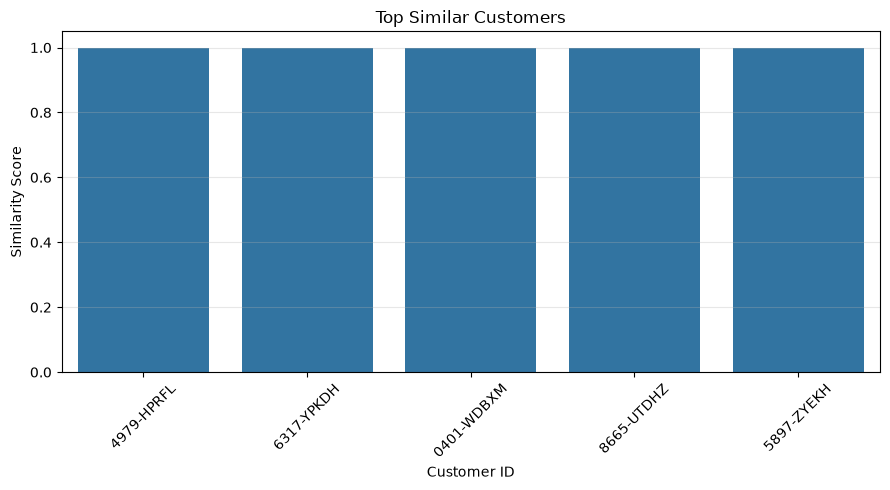

In [8]:
# Visualize similarity scores

plt.figure(figsize=(9, 5))

sns.barplot(
    data=recommendations,
    x="customerID",
    y="Similarity Score"
)

plt.title("Top Similar Customers")
plt.xlabel("Customer ID")
plt.ylabel("Similarity Score")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [9]:
# Identify customer service features

service_features = [
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

print("Service features:")
for feature in service_features:
    print("-", feature)

Service features:
- PhoneService
- MultipleLines
- InternetService
- OnlineSecurity
- OnlineBackup
- DeviceProtection
- TechSupport
- StreamingTV
- StreamingMovies


In [10]:
# Function to recommend services based on similar customers

def recommend_services(customer_index, top_n_customers=10):
    scores = similarity_matrix[customer_index]

    similar_indices = np.argsort(scores)[::-1]
    similar_indices = similar_indices[similar_indices != customer_index]
    similar_indices = similar_indices[:top_n_customers]

    similar_customers = data.loc[similar_indices]

    recommendations = {}

    for service in service_features:
        # Count customers using the service
        counts = similar_customers[service].value_counts()

        if len(counts) > 0:
            most_common = counts.index[0]

            # Recommend only when the most common option represents an actual service
            if most_common not in ["No", "No internet service", "No phone service"]:
                recommendations[service] = most_common

    return recommendations

In [11]:
# Generate service recommendations for the selected customer

service_recommendations = recommend_services(customer_index)

print("Service Recommendations")
print("=" * 50)

for service, recommendation in service_recommendations.items():
    print(f"{service}: {recommendation}")

Service Recommendations
PhoneService: Yes
MultipleLines: Yes
InternetService: Fiber optic
OnlineBackup: Yes


In [12]:
# Evaluate recommendation relevance using similarity scores

average_similarity = recommendations["Similarity Score"].mean()
maximum_similarity = recommendations["Similarity Score"].max()
minimum_similarity = recommendations["Similarity Score"].min()

print("Recommendation Relevance Evaluation")
print("=" * 50)
print(f"Average Similarity Score: {average_similarity:.3f}")
print(f"Maximum Similarity Score: {maximum_similarity:.3f}")
print(f"Minimum Similarity Score: {minimum_similarity:.3f}")

Recommendation Relevance Evaluation
Average Similarity Score: 1.000
Maximum Similarity Score: 1.000
Minimum Similarity Score: 1.000


In [13]:
# Save similarity-based recommendation results

recommendations.to_csv(
    "customer_similarity_recommendations.csv",
    index=False
)

print("Recommendation output saved successfully!")

Recommendation output saved successfully!


In [14]:
# Save service recommendations

service_report = pd.DataFrame(
    list(service_recommendations.items()),
    columns=["Service", "Recommended Option"]
)

service_report.to_csv(
    "service_recommendations.csv",
    index=False
)

print("Service recommendation report saved successfully!")
display(service_report)

Service recommendation report saved successfully!


,Service,Recommended Option
0,PhoneService,Yes
1,MultipleLines,Yes
2,InternetService,Fiber optic
3,OnlineBackup,Yes


In [15]:
# Create personalization strategy report

personalization_strategies = {
    "Similarity-Based Recommendations":
        "Recommend services by analyzing the services commonly used by customers with similar tenure and spending patterns.",
    
    "High-Value Customer Personalization":
        "Provide relevant premium or additional services to customers with longer tenure and higher spending.",
    
    "New Customer Personalization":
        "Use similar-customer behavior to suggest useful services and encourage continued adoption.",
    
    "Retention Strategy":
        "Use customer similarity to identify customers with comparable characteristics and design targeted retention campaigns."
}

print("Personalization Strategies")
print("=" * 60)

for strategy, description in personalization_strategies.items():
    print(f"\n{strategy}")
    print(description)

Personalization Strategies

Similarity-Based Recommendations
Recommend services by analyzing the services commonly used by customers with similar tenure and spending patterns.

High-Value Customer Personalization
Provide relevant premium or additional services to customers with longer tenure and higher spending.

New Customer Personalization
Use similar-customer behavior to suggest useful services and encourage continued adoption.

Retention Strategy
Use customer similarity to identify customers with comparable characteristics and design targeted retention campaigns.


In [16]:
# Save personalization strategies

with open("personalization_strategy_report.txt", "w") as file:
    for strategy, description in personalization_strategies.items():
        file.write(f"{strategy}\n")
        file.write("-" * 50 + "\n")
        file.write(description + "\n\n")

print("Personalization strategy report saved successfully!")

Personalization strategy report saved successfully!


In [17]:
# Check Day 32 output files

import os

day32_files = [
    "recommendation_system.ipynb",
    "customer_similarity_recommendations.csv",
    "service_recommendations.csv",
    "personalization_strategy_report.txt"
]

print("Day 32 Output Files")
print("=" * 50)

for file in day32_files:
    status = "✓ Found" if os.path.exists(file) else "✗ Missing"
    print(f"{status}: {file}")

Day 32 Output Files
✓ Found: recommendation_system.ipynb
✓ Found: customer_similarity_recommendations.csv
✓ Found: service_recommendations.csv
✓ Found: personalization_strategy_report.txt
